# Simulate Disk and Rectangle

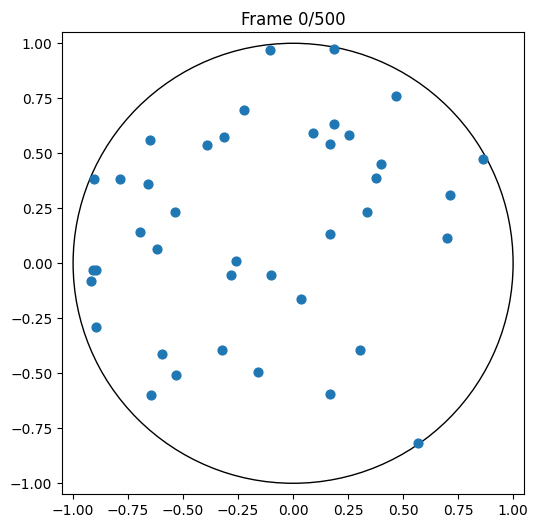

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# ----------------------------
# Domains
# ----------------------------

class Rectangle:
    def __init__(self, width=1.0, height=1.0):
        self.width = width
        self.height = height

    def sample(self, n):
        return np.column_stack([
            self.width * np.random.rand(n),
            self.height * np.random.rand(n),
        ])

    def project(self, x):
        x[:, 0] = np.clip(x[:, 0], 0, self.width)
        x[:, 1] = np.clip(x[:, 1], 0, self.height)
        return x

    def draw(self, ax):
        ax.add_patch(plt.Rectangle((0, 0), self.width, self.height, fill=False))
        ax.set_xlim(-0.05 * self.width, 1.05 * self.width)
        ax.set_ylim(-0.05 * self.height, 1.05 * self.height)


class Disk:
    def __init__(self, radius=1.0):
        self.radius = radius

    def sample(self, n):
        theta = 2 * np.pi * np.random.rand(n)
        r = self.radius * np.sqrt(np.random.rand(n))
        return np.column_stack([r * np.cos(theta), r * np.sin(theta)])

    def project(self, x):
        r = np.linalg.norm(x, axis=1)
        outside = r > self.radius
        x[outside] *= (self.radius / r[outside])[:, None]
        return x

    def draw(self, ax):
        ax.add_patch(plt.Circle((0, 0), self.radius, fill=False))
        ax.set_xlim(-1.05 * self.radius, 1.05 * self.radius)
        ax.set_ylim(-1.05 * self.radius, 1.05 * self.radius)


# ----------------------------
# Forces
# ----------------------------

def repulsive_forces(x, kind="inverse_power", p=2.0, sigma=0.1, eps=1e-6):
    """
    Returns force on each particle.

    For inverse_power:
        V(r) = 1 / r^p

    For exponential:
        V(r) = exp(-r / sigma)
    """
    n = len(x)
    forces = np.zeros_like(x)

    for i in range(n):
        for j in range(i + 1, n):
            rij = x[i] - x[j]
            r = np.linalg.norm(rij) + eps
            direction = rij / r

            if kind == "inverse_power":
                # V = r^{-p}
                # F = -grad V = p r^{-p-1} direction
                f = p * r ** (-p - 1) * direction

            elif kind == "exponential":
                # V = exp(-r/sigma)
                # F = (1/sigma) exp(-r/sigma) direction
                f = (1 / sigma) * np.exp(-r / sigma) * direction

            elif kind == "gaussian":
                # V = exp(-(r/sigma)^2)
                # F = 2r/sigma^2 exp(-(r/sigma)^2) direction
                f = (2 * r / sigma**2) * np.exp(-(r / sigma) ** 2) * direction

            else:
                raise ValueError(f"Unknown force kind: {kind}")

            forces[i] += f
            forces[j] -= f

    return forces


# ----------------------------
# Time evolution
# ----------------------------

def simulate(
    n=30,
    domain=None,
    kind="inverse_power",
    p=2.0,
    sigma=0.1,
    dt=1e-3,
    steps=5000,
    mobility=1.0,
    noise_strength=0.0,
    damping_clip=10.0,
    save_every=10,
    seed=0,
):
    np.random.seed(seed)

    if domain is None:
        domain = Disk(radius=1.0)

    x = domain.sample(n)
    trajectory = [x.copy()]

    for step in range(steps):
        forces = repulsive_forces(x, kind=kind, p=p, sigma=sigma)
        #forces += wall_force(domain, x, strength=500.0, d0=0.02)

        # Optional clipping avoids numerical explosions when particles get too close.
        norms = np.linalg.norm(forces, axis=1)
        too_large = norms > damping_clip
        forces[too_large] *= (damping_clip / norms[too_large])[:, None]

        noise = noise_strength * np.sqrt(dt) * np.random.randn(n, 2)

        x = x + mobility * dt * forces + noise
        x = domain.project(x)

        if step % save_every == 0:
            trajectory.append(x.copy())

    return np.array(trajectory)


# ----------------------------
# Animation
# ----------------------------

def animate_trajectory(trajectory, domain, interval=30):
    fig, ax = plt.subplots(figsize=(6, 6))
    domain.draw(ax)
    ax.set_aspect("equal")

    scat = ax.scatter(trajectory[0, :, 0], trajectory[0, :, 1], s=40)

    def update(frame):
        scat.set_offsets(trajectory[frame])
        ax.set_title(f"Frame {frame}/{len(trajectory)-1}")
        return scat,

    anim = FuncAnimation(
        fig,
        update,
        frames=len(trajectory),
        interval=interval,
        blit=True,
    )

    plt.show()
    return anim


# ----------------------------
# Example
# ----------------------------


domain = Disk(radius=1.0)
# domain = Rectangle(width=1.0, height=1.0)

trajectory = simulate(
    n=40,
    domain=domain,
    kind="inverse_power",
    p=1.0,
    dt=2e-3,
    steps=500,
    save_every=1,
    damping_clip=20.0,
    noise_strength=1.0,
    seed=2,
)

anim = animate_trajectory(trajectory, domain)
anim.save("/home/jlangbehn/documents/private/gen_art/packing_problems/output/anim.mp4", fps=30, dpi=100)

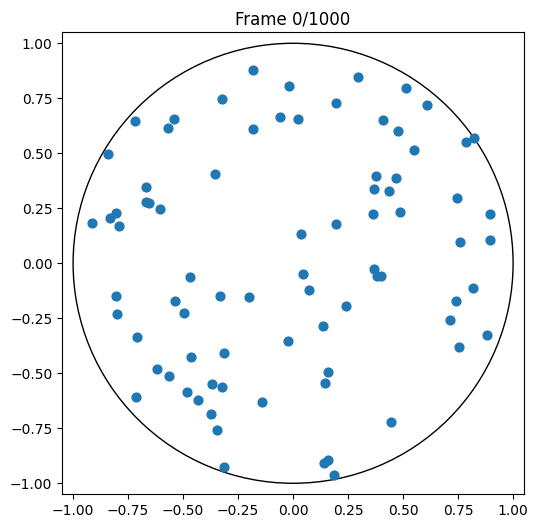

In [8]:
trajectory = simulate(
    n=80,
    domain=Disk(radius=1.0),
    kind="exponential",
    sigma=0.15,
    dt=5e-3,
    steps=1000,
    save_every=1,
)

anim = animate_trajectory(trajectory, domain)
anim.save("/home/jlangbehn/documents/private/gen_art/packing_problems/output/anim2.mp4", fps=30, dpi=100)

# Random shape soft wall

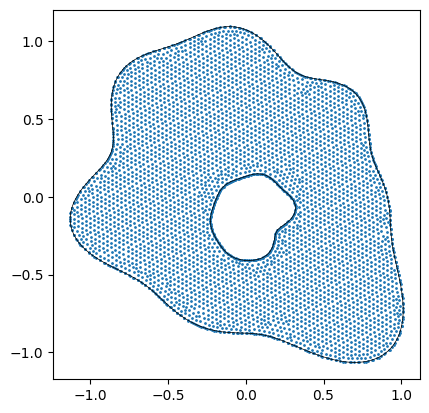

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 75.25it/s]

Simulation time: 6.65 s


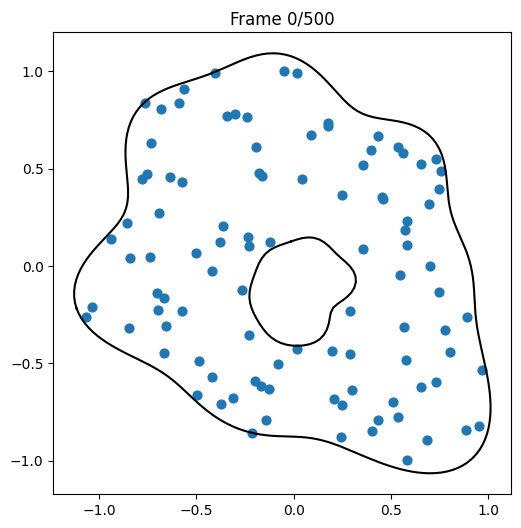

Animation time: 0.04 s
Saving animation time: 8.92 s


In [ ]:
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

from chladni_eigenmodes.fem_utils import meshio_to_points_triangles, hdf5_filename_for_source, save_fem_solution_hdf5

import numpy as np
import meshio
from shapely.geometry import Polygon
from collections import defaultdict
from shapely.geometry import Point, LineString
from shapely.ops import polygonize, unary_union, nearest_points
from shapely.prepared import prep
import time
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import tqdm
import matplotlib.tri as tri

# ------------------------------------------------------------
# Load triangulated gmsh domain as shapely polygon
# ------------------------------------------------------------

def load_domain_from_msh(filename, simplify_tol=0.0):
    mesh = meshio.read(filename)
    points = mesh.points[:, :2]

    triangles = []
    for cell_block in mesh.cells:
        if cell_block.type == "triangle":
            triangles.append(cell_block.data)

    if not triangles:
        raise ValueError("No triangle cells found in mesh.")

    triangles = np.vstack(triangles)

    tri_polygons = []
    for tri in triangles:
        coords = points[tri]
        poly = Polygon(coords)

        if poly.is_valid and poly.area > 0:
            tri_polygons.append(poly)

    if not tri_polygons:
        raise RuntimeError("No valid triangle polygons constructed.")

    geometry = unary_union(tri_polygons)

    if simplify_tol > 0:
        geometry = geometry.simplify(simplify_tol, preserve_topology=True)

    if not geometry.is_valid:
        geometry = geometry.buffer(0)

    return MeshDomain(geometry)

# ------------------------------------------------------------
# Domain with signed-distance wall potential
# ------------------------------------------------------------

class MeshDomain:
    def __init__(self, geometry):
        """
        geometry: shapely Polygon or MultiPolygon.
        May contain holes.
        """
        self.geometry = geometry
        self.boundary = geometry.boundary
        self.prepared = prep(geometry)
        self.minx, self.miny, self.maxx, self.maxy = geometry.bounds

    def contains(self, p):
        return self.prepared.contains(Point(float(p[0]), float(p[1])))

    def signed_distance(self, p):
        point = Point(float(p[0]), float(p[1]))
        d = point.distance(self.boundary)

        if self.prepared.contains(point):
            return d
        else:
            return -d

    def sample(self, n):
        pts = []
        while len(pts) < n:
            p = np.array([
                np.random.uniform(self.minx, self.maxx),
                np.random.uniform(self.miny, self.maxy),
            ])
            if self.contains(p):
                pts.append(p)

        return np.array(pts)

    def nearest_boundary_direction(self, p):
        """
        Returns approximate inward normal direction using nearest boundary point.
        """
        point = Point(float(p[0]), float(p[1]))
        _, nearest = nearest_points(point, self.boundary)

        q = np.array([nearest.x, nearest.y])
        v = np.asarray(p) - q
        norm = np.linalg.norm(v)

        if norm < 1e-12:
            return np.zeros(2)

        # If p is inside, v points inward away from boundary.
        # If p is outside, -v usually points back toward boundary/interior.
        if self.contains(p):
            return v / norm
        else:
            return -v / norm

    def draw(self, ax):
        """
        Draw polygon / multipolygon including holes.
        """

        geometries = getattr(self.geometry, "geoms", [self.geometry])

        for geom in geometries:

            # Outer boundary
            x, y = geom.exterior.xy
            ax.plot(x, y, color="black")

            # Holes
            for interior in geom.interiors:
                xh, yh = interior.xy
                ax.plot(xh, yh, color="black")

        ax.set_aspect("equal")

        pad_x = 0.05 * (self.maxx - self.minx)
        pad_y = 0.05 * (self.maxy - self.miny)

        ax.set_xlim(self.minx - pad_x, self.maxx + pad_x)
        ax.set_ylim(self.miny - pad_y, self.maxy + pad_y)


# ------------------------------------------------------------
# Soft wall force
# ------------------------------------------------------------

def wall_force(domain, x, wall_strength=100.0, d0=0.05):
    """
    Soft repulsive wall force.

    phi > 0 inside domain
    phi < 0 outside domain

    E_wall = strength * max(0, d0 - phi)^2

    Force:
        F = -grad E_wall
          = 2 * strength * (d0 - phi) * grad(phi)

    Here grad(phi) is approximated geometrically from the nearest boundary point.
    """
    forces = np.zeros_like(x)

    for i, p in enumerate(x):
        phi = domain.signed_distance(p)

        if phi >= d0:
            continue

        normal = domain.nearest_boundary_direction(p)

        forces[i] = 2.0 * wall_strength * (d0 - phi) * normal

    return forces

def repulsive_forces(x, kind="inverse_power", p=2.0, sigma=0.1, eps=1e-6):
    """
    Returns force on each particle.

    For inverse_power:
        V(r) = 1 / r^p

    For exponential:
        V(r) = exp(-r / sigma)
    """
    n = len(x)
    forces = np.zeros_like(x)

    for i in range(n):
        for j in range(i + 1, n):
            rij = x[i] - x[j]
            r = np.linalg.norm(rij) + eps
            direction = rij / r

            if kind == "inverse_power":
                # V = r^{-p}
                # F = -grad V = p r^{-p-1} direction
                f = p * r ** (-p - 1) * direction

            elif kind == "exponential":
                # V = exp(-r/sigma)
                # F = (1/sigma) exp(-r/sigma) direction
                f = (1 / sigma) * np.exp(-r / sigma) * direction

            elif kind == "gaussian":
                # V = exp(-(r/sigma)^2)
                # F = 2r/sigma^2 exp(-(r/sigma)^2) direction
                f = (2 * r / sigma**2) * np.exp(-(r / sigma) ** 2) * direction

            else:
                raise ValueError(f"Unknown force kind: {kind}")

            forces[i] += f
            forces[j] -= f

    return forces

def plot_mesh(m, lines=True, triangles=True, points=True):
    """
    Plot a meshio mesh object.

    Parameters
    ----------
    m : meshio.Mesh
        Mesh to plot
    """
    _, ax = plt.subplots()
    if points:
        ax.scatter(m.points[:, 0], m.points[:, 1], s=1)
    if "line" in m.cells_dict and lines:
        for l in m.cells_dict["line"]:
            ax.plot(m.points[l, 0], m.points[l, 1], "k-", lw=0.5)
    if "triangle" in m.cells_dict and triangles:
        for t in m.cells_dict["triangle"]:
            ax.plot(m.points[t[[0, 1, 2, 0]], 0], m.points[t[[0, 1, 2, 0]], 1], "r-", lw=0.5)

    ax.set_aspect("equal")
    plt.show()

# ============================================================
# Eigenmode interpolation and restoring forces
# ============================================================

class EigenmodePotentialField:
    """
    Piecewise-linear representation of an eigenmode over a mesh, with precomputed
    triangle coefficients and gradient data for the potential V = |psi|^2.
    """
    def __init__(self, points, triangles, eigenvector):
        self.points = points
        self.triangles = triangles
        self.eigenvector = eigenvector
        self.V = np.abs(self.eigenvector) ** 2

        self.triang = tri.Triangulation(points[:, 0], points[:, 1], triangles)
        self.trifinder = self.triang.get_trifinder()
        self.triangle_data = self._precompute_triangle_data()

    def _precompute_triangle_data(self):
        data = []
        for tri_indices in self.triangles:
            p = self.points[tri_indices]
            psi = self.eigenvector[tri_indices]

            A = np.column_stack([np.ones(3), p[:, 0], p[:, 1]])
            a, b, c = np.linalg.solve(A, psi)

            data.append({
                "coeff": np.array([a, b, c]),
                "grad_psi": np.array([b, c]),
            })

        return data

    def _find_triangle(self, x, y):
        return self.trifinder(x, y)

    def psi_at(self, x, y):
        tri_idx = self._find_triangle(x, y)
        if tri_idx == -1:
            return 0.0

        a, b, c = self.triangle_data[tri_idx]["coeff"]
        return a + b * x + c * y

    def gradient(self, x, y):
        tri_idx = self._find_triangle(x, y)
        if tri_idx == -1:
            return np.zeros(2)

        psi_xy = self.psi_at(x, y)
        grad_psi = self.triangle_data[tri_idx]["grad_psi"]
        return 2 * np.real(np.conj(psi_xy) * grad_psi)

    def force_at(self, x, y):
        return -self.gradient(x, y)


def eigenmode_restoring_force(x, eigenmode_field, restoring_strength=1.0, sigma=0.1):
    """
    Compute restoring forces toward nodal lines of an eigenmode.
    
    The force is proportional to the eigenmode value: particles are pushed toward
    regions where the eigenmode is close to zero (nodal lines).
    
    Parameters
    ----------
    x : (n, 2) array
        Particle positions
    eigenmode_field : EigenmodeField
        Interpolated eigenmode data
    restoring_strength : float
        Strength of restoring force
    sigma : float
        Gaussian smoothing width for smoother forces near nodal lines
    
    Returns
    -------
    forces : (n, 2) array
        Restoring forces on each particle
    """
    n = len(x)
    forces = np.zeros_like(x)
    
    for i in range(n):
        p = x[i]
        #u = eigenmode_field.evaluate(p)
        #grad_u = eigenmode_field.gradient(p)
        
        ## Force toward regions where u ≈ 0 (nodal lines)
        ## Using a Gaussian-like weighting: force ~ u * exp(-(u/sigma)^2) * grad(u)
        #weight = np.exp(-(u / sigma) ** 2)
        #forces[i] = -restoring_strength * u * weight * grad_u
        forces[i] = eigenmode_field.force_at(*p)
    
    return forces

def simulate(
    n=30,
    domain=None,
    kind="inverse_power",
    p=2.0,
    sigma=0.1,
    dt=1e-3,
    steps=5000,
    mobility=1.0,
    noise_strength=0.0,
    damping_clip=10.0,
    save_every=10,
    wall_strength=500.0,
    d0=0.02,
    eigenmode_field=None,
    eigenmode_strength=0.0,
    seed=0,
):
    np.random.seed(seed)

    if domain is None:
        domain = Disk(radius=1.0)

    x = domain.sample(n)
    trajectory = [x.copy()]

    for step in tqdm.tqdm(range(steps), total=steps):
        forces = repulsive_forces(x, kind=kind, p=p, sigma=sigma)
        
        # Add eigenmode restoring force toward nodal lines if eigenmode_field is provided
        if eigenmode_field is not None and eigenmode_strength > 0.0:
            forces += eigenmode_restoring_force(x, eigenmode_field, restoring_strength=eigenmode_strength)

        # Optional clipping avoids numerical explosions when particles get too close.
        norms = np.linalg.norm(forces, axis=1)
        too_large = norms > damping_clip
        forces[too_large] *= (damping_clip / norms[too_large])[:, None]
        forces += wall_force(domain, x, wall_strength=wall_strength, d0=d0)

        noise = noise_strength * np.sqrt(dt) * np.random.randn(n, 2)

        x = x + mobility * dt * forces + noise

        if step % save_every == 0:
            trajectory.append(x.copy())

    return np.array(trajectory)


# ----------------------------
# Animation
# ----------------------------

def animate_trajectory(trajectory, domain, interval=30):
    fig, ax = plt.subplots(figsize=(6, 6))
    domain.draw(ax)
    ax.set_aspect("equal")

    scat = ax.scatter(trajectory[0, :, 0], trajectory[0, :, 1], s=40)

    def update(frame):
        scat.set_offsets(trajectory[frame])
        ax.set_title(f"Frame {frame}/{len(trajectory)-1}")
        return scat,

    anim = FuncAnimation(
        fig,
        update,
        frames=len(trajectory),
        interval=interval,
        blit=True,
    )

    plt.show()
    return anim

#fem_file = "/home/jlangbehn/documents/private/generative_art/chladni_eigenmodes/output/random_shape_fem.h5"
#data = load_fem_solution_hdf5(fem_file)

mesh_file = "/home/jlangbehn/documents/private/gen_art/packing_problems/output/random_shape.msh"
mesh = meshio.read(mesh_file)
domain = load_domain_from_msh(mesh_file)

plot_mesh(mesh, triangles=False, points=True)

t0 = time.time()
trajectory = simulate(
    n=100,
    domain=domain,
    kind="inverse_power",
    p=1.0,
    dt=1e-3,
    steps=500,
    save_every=1,
    damping_clip=20.0,
    noise_strength=0.0,
    wall_strength=200.0,
    eigenmode_field=None,
    eigenmode_strength=0.0,
    d0=0.05,
    seed=2,
)
t1 = time.time()
print(f"Simulation time: {t1 - t0:.2f} s")

t0 = time.time()
anim = animate_trajectory(trajectory, domain)
t1 = time.time()
print(f"Animation time: {t1 - t0:.2f} s")

t0 = time.time()
anim.save("/home/jlangbehn/documents/private/gen_art/packing_problems/output/anim3.mp4", fps=30, dpi=100)
t1 = time.time()
print(f"Saving animation time: {t1 - t0:.2f} s")

In [28]:
# Load FEM solution for eigenmode data

import h5py

def load_fem_solution_hdf5(filename):
    """Load FEM solution from HDF5 file."""
    with h5py.File(filename, "r") as f:
        points = np.array(f["mesh/points"])
        triangles = np.array(f["mesh/triangles"])
        eigenvalues = np.array(f["modes/eigenvalues"])
        eigenvectors = np.array(f["modes/eigenvectors"])
        metadata = {
            "source_mesh_file": f.attrs.get("source_mesh_file", ""),
            "source_mesh_name": f.attrs.get("source_mesh_name", ""),
            "n_points": int(f.attrs.get("n_points", points.shape[0])),
            "n_triangles": int(f.attrs.get("n_triangles", triangles.shape[0])),
            "n_modes": int(f.attrs.get("n_modes", eigenvectors.shape[0])),
        }
    return {
        "points": points,
        "triangles": triangles,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "metadata": metadata,
    }

# Simulation with Eigenmode Restoring Forces

Loaded 100 eigenmodes
Using mode 5 with eigenvalue 44.6599
Mesh has 4031 points and 7776 triangles


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 4005.56it/s]


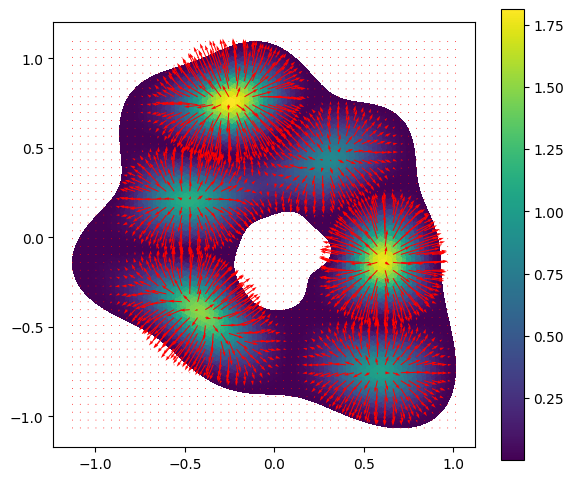

In [89]:
# Load FEM solution and select an eigenmode
fem_file = "/home/jlangbehn/documents/private/generative_art/chladni_eigenmodes/output/random_shape_fem.h5"
fem_data = load_fem_solution_hdf5(fem_file)

# Select the eigenmode to use (0 = first mode)
mode_idx = 5
eigenmode = fem_data["eigenvectors"][mode_idx]
mesh_points = fem_data["points"]
mesh_triangles = fem_data["triangles"]

print(f"Loaded {fem_data['metadata']['n_modes']} eigenmodes")
print(f"Using mode {mode_idx} with eigenvalue {fem_data['eigenvalues'][mode_idx]:.4f}")
print(f"Mesh has {fem_data['metadata']['n_points']} points and {fem_data['metadata']['n_triangles']} triangles")

# Create EigenmodeField object for interpolation
eigenmode_field = EigenmodePotentialField(mesh_points, mesh_triangles, eigenmode)

V = eigenmode_field.V

triang = eigenmode_field.triang
interp = tri.LinearTriInterpolator(triang, eigenmode)

xq = np.linspace(mesh_points[:, 0].min(), mesh_points[:, 0].max(), 50)
yq = np.linspace(mesh_points[:, 1].min(), mesh_points[:, 1].max(), 50)

X, Y = np.meshgrid(xq, yq)
uq = np.zeros_like(X)
vq = np.zeros_like(Y)
for iy, y in tqdm.tqdm(enumerate(yq), total=len(yq)):
    for ix, x in enumerate(xq):
        uq[iy, ix], vq[iy, ix] = eigenmode_field.force_at(x, y) / 10

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the potential V and its force field
tcf = ax.tripcolor(triang, V, cmap='viridis')
ax.quiver(X, Y, uq, vq, color='red', angles='xy', scale_units='xy', scale=5)
ax.set_aspect('equal')
plt.colorbar(tcf, ax=ax)
plt.tight_layout()
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:34<00:00,  3.23it/s]

Simulation time: 154.88 s


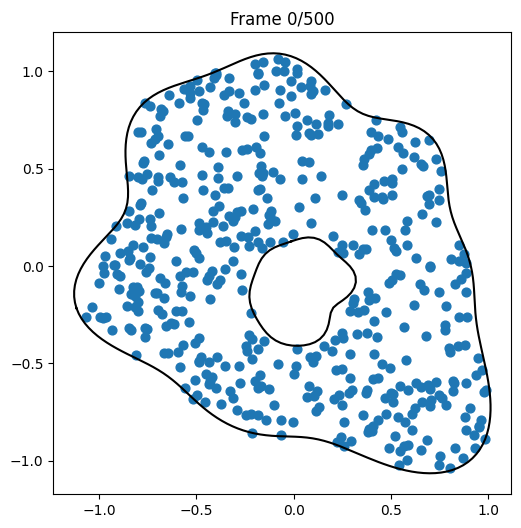

Animation saved!


In [ ]:
# Run simulation with eigenmode restoring force
# Particles will be attracted to the nodal lines (where eigenmode ≈ 0)

t0 = time.time()
trajectory_with_eigenmode = simulate(
    n=100,
    domain=domain,
    kind="exponential",
    p=1.0,
    sigma=0.01,
    dt=1e-3,
    steps=500,
    save_every=1,
    damping_clip=20.0,
    noise_strength=0.0,
    wall_strength=200.0,
    eigenmode_field=eigenmode_field,
    eigenmode_strength=100.0,
    d0=0.05,
    seed=2,
)

t1 = time.time()
print(f"Simulation time: {t1 - t0:.2f} s")

# Animate the trajectory
anim = animate_trajectory(trajectory_with_eigenmode, domain, interval=30)
anim.save("/home/jlangbehn/documents/private/generative_art/chladni_eigenmodes/output/eigenmode_pattern.mp4", fps=30, dpi=100)
print("Animation saved!")


## Parameter Guide

**Eigenmode Parameters:**
- `eigenmode_field`: The `EigenmodeField` object containing interpolated eigenmode data
- `eigenmode_strength`: Controls the magnitude of attraction to nodal lines
  - Higher values = stronger attraction to nodal lines
  - Try values between 0.5 and 20.0 depending on desired pattern strength

**Key Physics:**
- The restoring force is proportional to: $F = -\text{strength} \cdot u(\mathbf{x}) \cdot e^{-(u/\sigma)^2} \cdot \nabla u(\mathbf{x})$
- Where $u(\mathbf{x})$ is the eigenmode value at position $\mathbf{x}$
- Particles are pushed toward regions where $u \approx 0$ (the nodal lines)
- The Gaussian weight smooths the force to avoid singularities

**Typical Values:**
- `eigenmode_strength`: 1.0 - 10.0 for subtle effects, 10.0+ for strong patterning
- `noise_strength`: 0.0 - 0.5 to add randomness
- `damping_clip`: 20.0 - 50.0 to prevent unrealistic forces